In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 537.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 759.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.

100%|██████████| 269/269 [01:32<00:00,  2.90it/s]


Epoch 1 Loss: 1.0390


100%|██████████| 269/269 [01:34<00:00,  2.86it/s]


Epoch 2 Loss: 0.4430


...

Epoch 8 Loss: 0.0672


100%|██████████| 269/269 [01:35<00:00,  2.81it/s]


Epoch 9 Loss: 0.0571


100%|██████████| 269/269 [01:35<00:00,  2.81it/s]


Epoch 10 Loss: 0.0466


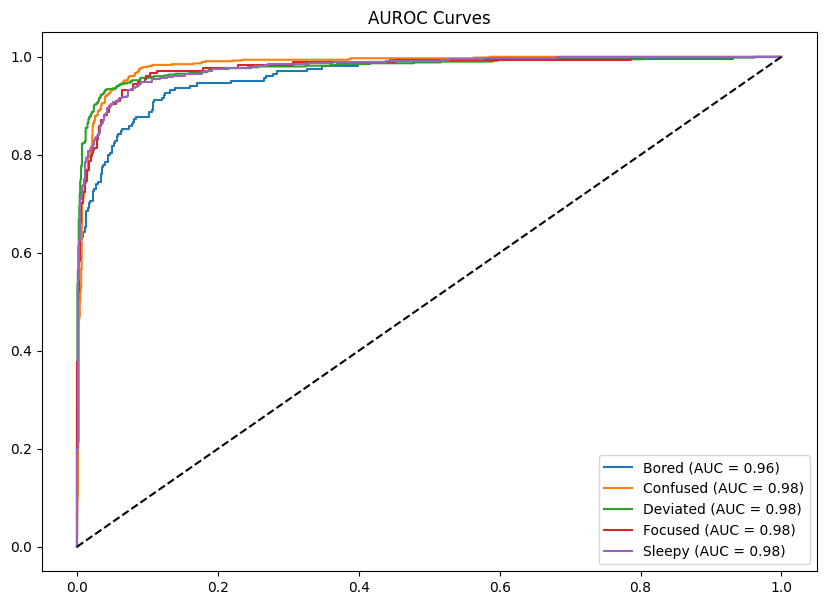


Classification Report:
              precision    recall  f1-score   support

       Bored       0.81      0.70      0.75       204
    Confused       0.87      0.94      0.91       663
    Deviated       0.90      0.93      0.91       606
     Focused       0.83      0.76      0.79       178
      Sleepy       0.89      0.84      0.86       497

    accuracy                           0.88      2148
   macro avg       0.86      0.83      0.85      2148
weighted avg       0.87      0.88      0.87      2148



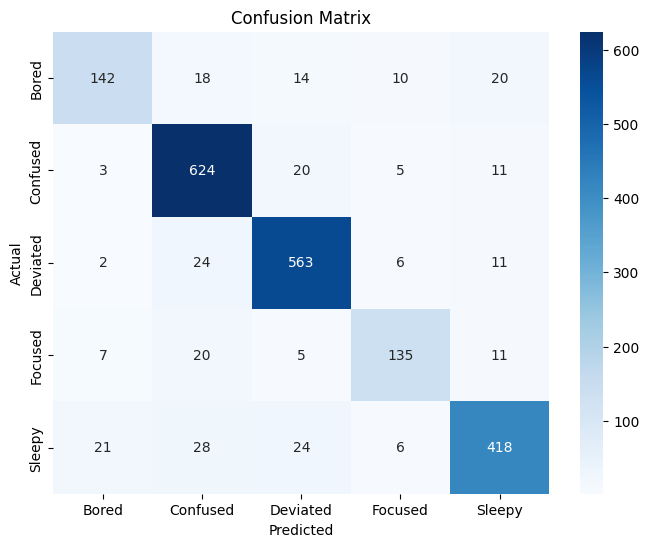


--- Upload an image for Classroom Engagement Analysis ---


Saving frame_1.jpg to frame_1.jpg


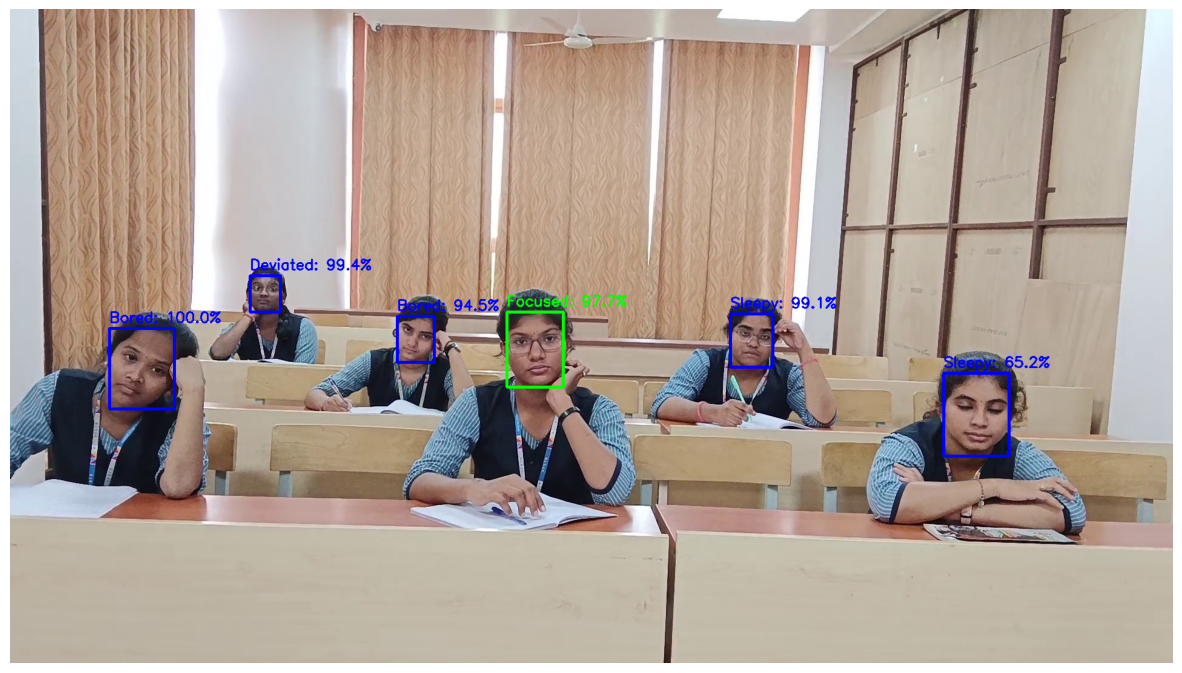

In [ ]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive, files
from PIL import Image

# Install face detection library
!pip install facenet-pytorch -q
from facenet_pytorch import MTCNN

drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASS_NAMES = ['Bored', 'Confused', 'Deviated', 'Focused', 'Sleepy']

TRAIN_DIR = '/content/drive/MyDrive/cropped_dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/models/engagement_model.pth'

class EngagementDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def load_data(base_path):
    images, labels = [], []
    if not os.path.exists(base_path):
        print(f"ERROR: Base path not found: {base_path}")
        return np.array([]), np.array([])

    existing_folders = os.listdir(base_path)
    for idx, class_name in enumerate(CLASS_NAMES):
        target_folder = next((f for f in existing_folders if f.lower() == class_name.lower()), None)
        if target_folder is None: continue

        class_path = os.path.join(base_path, target_folder)
        file_list = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for filename in file_list:
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(idx)
    return np.array(images), np.array(labels)

X, y = load_data(TRAIN_DIR)
if len(X) == 0:
    raise ValueError(f"No images found in {TRAIN_DIR}.")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(EngagementDataset(X_train, y_train, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EngagementDataset(X_val, y_val, transform), batch_size=BATCH_SIZE)

class EngagementModel(nn.Module):
    def __init__(self, num_classes):
        super(EngagementModel, self).__init__()
        self.base = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1).features
        self.conv = nn.Conv2d(1024, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.base(x)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model = EngagementModel(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, lbls in tqdm(train_loader):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), MODEL_SAVE_PATH)

# Evaluation
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        output = torch.softmax(model(imgs), dim=1)
        all_probs.append(output.cpu().numpy())
        all_labels.append(lbls.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)
y_pred = np.argmax(all_probs, axis=1)

# AUROC
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
plt.figure(figsize=(10, 7))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("AUROC Curves")
plt.legend()
plt.show()

# Classification Report & Confusion Matrix
print("\nClassification Report:")
print(classification_report(all_labels, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Multi-Face Detection and Prediction
def predict_uploaded_image_multi():
    mtcnn = MTCNN(keep_all=True, device=device)
    print("\n--- Upload an image for Classroom Engagement Analysis ---")
    uploaded = files.upload()

    for fn in uploaded.keys():
        img = cv2.imread(fn)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Detect all faces
        boxes, _ = mtcnn.detect(img_rgb)

        if boxes is not None:
            for box in boxes:
                x1, y1, x2, y2 = [int(b) for b in box]
                face = img_rgb[y1:y2, x1:x2]

                if face.size == 0: continue

                # Preprocess face for classifier
                face_resized = cv2.resize(face, IMG_SIZE)
                face_tensor = transform(face_resized).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model(face_tensor)
                    probs = torch.softmax(output, dim=1).cpu().numpy()[0]

                idx = np.argmax(probs)
                label = f"{CLASS_NAMES[idx]}: {probs[idx]*100:.1f}%"

                # Color coding (Red for Bored/Sleepy/Confused, Blue for Deviated, Green for Focused)
                color = (0, 255, 0) if CLASS_NAMES[idx] == 'Focused' else (255, 0, 0)
                if CLASS_NAMES[idx] in ['Bored', 'Sleepy', 'Confused']: color = (255, 0, 0) # Red/Blue matching your style

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        plt.figure(figsize=(15, 10))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

predict_uploaded_image_multi()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 10: 100%|██████████| 269/269 [01:26<00:00,  3.10it/s]



Classification Report:
               precision    recall  f1-score   support

       Bored       0.83      0.62      0.71       204
    Confused       0.88      0.88      0.88       663
    Deviated       0.94      0.91      0.93       606
     Focused       0.83      0.78      0.80       178
      Sleepy       0.79      0.92      0.85       497

    accuracy                           0.86      2148
   macro avg       0.85      0.82      0.83      2148
weighted avg       0.87      0.86      0.86      2148



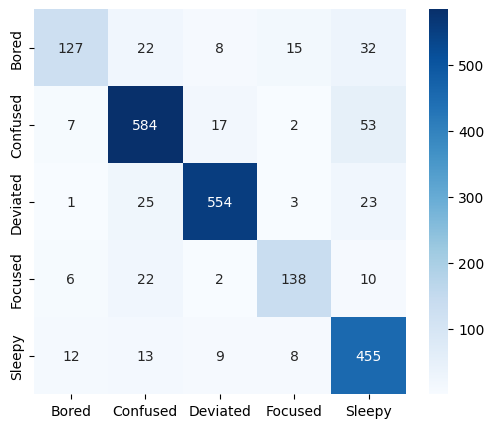


Overall Engagement Index: -0.5076
Random Engagement Index: -0.3000


Saving frame_1.jpg to frame_1 (1).jpg


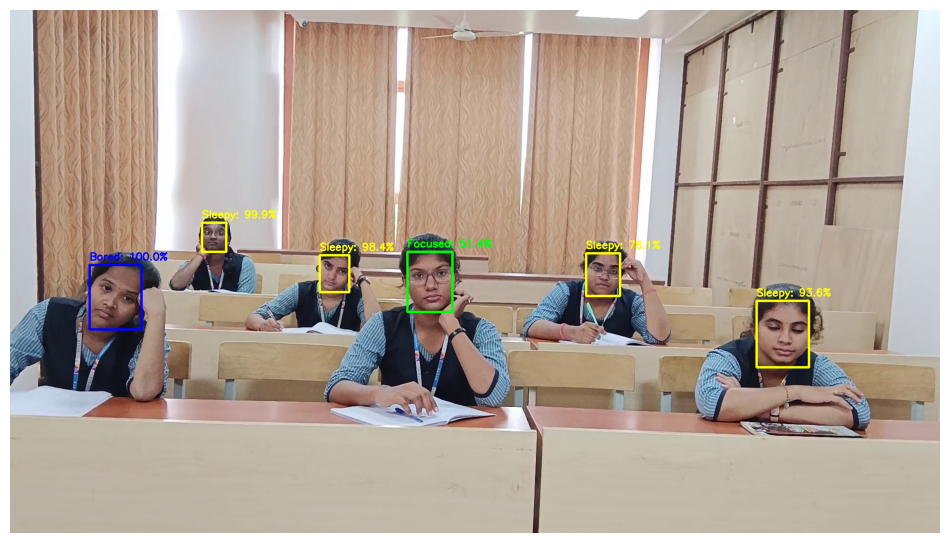

In [ ]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import drive, files
from PIL import Image

# Install and import face detection library
!pip install facenet-pytorch -q
from facenet_pytorch import MTCNN

drive.mount('/content/drive')

# ============================== Configuration ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASS_NAMES = ['Bored', 'Confused', 'Deviated', 'Focused', 'Sleepy']

# Define colors for each class (BGR format)
CLASS_COLORS = {
    'Bored': (255, 0, 0),      # Blue
    'Confused': (0, 0, 255),    # Red
    'Deviated': (255, 255, 0),  # Cyan
    'Focused': (0, 255, 0),     # Green
    'Sleepy': (0, 255, 255)     # Yellow
}

TRAIN_DIR = '/content/drive/MyDrive/cropped_dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/models/engagement_model.pth'

# ============================== Dataset & Model ==============================
class EngagementDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def load_data(base_path):
    images, labels = [], []
    existing_folders = os.listdir(base_path)
    for idx, class_name in enumerate(CLASS_NAMES):
        target_folder = next((f for f in existing_folders if f.lower() == class_name.lower()), None)
        if target_folder:
            path = os.path.join(base_path, target_folder)
            for fn in os.listdir(path):
                if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = cv2.imread(os.path.join(path, fn))
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        images.append(cv2.resize(img, IMG_SIZE))
                        labels.append(idx)
    return np.array(images), np.array(labels)

class EngagementModel(nn.Module):
    def __init__(self, num_classes):
        super(EngagementModel, self).__init__()
        self.base = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1).features
        self.conv = nn.Conv2d(1024, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.base(x)
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# ============================== Processing ==============================
X, y = load_data(TRAIN_DIR)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(EngagementDataset(X_train, y_train, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EngagementDataset(X_val, y_val, transform), batch_size=BATCH_SIZE)

model = EngagementModel(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Simple Training Loop
for epoch in range(10):
    model.train()
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(); output = model(imgs); loss = criterion(output, lbls)
        loss.backward(); optimizer.step()

torch.save(model.state_dict(), MODEL_SAVE_PATH)

# ============================== Metrics & Indices ==============================
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        output = torch.softmax(model(imgs.to(device)), dim=1)
        all_probs.append(output.cpu().numpy()); all_labels.append(lbls.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)
y_pred = np.argmax(all_probs, axis=1)

# AUROC and Confusion Matrix
print("\nClassification Report:\n", classification_report(all_labels, y_pred, target_names=CLASS_NAMES))
plt.figure(figsize=(6, 5)); sns.heatmap(confusion_matrix(all_labels, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES); plt.show()

# Engagement Indices
weights = np.array([-0.5, -0.2, -0.8, 1.0, -1.0]) # Bored, Confused, Deviated, Focused, Sleepy
avg_probs = np.mean(all_probs, axis=0)
overall_engagement = np.dot(avg_probs, weights)
random_engagement = np.dot(np.full(NUM_CLASSES, 1/NUM_CLASSES), weights)

print(f"\nOverall Engagement Index: {overall_engagement:.4f}")
print(f"Random Engagement Index: {random_engagement:.4f}")

# ============================== Final Inference ==============================
def predict_with_colors():
    mtcnn = MTCNN(keep_all=True, device=device)
    uploaded = files.upload()
    for fn in uploaded.keys():
        img = cv2.imread(fn)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        boxes, _ = mtcnn.detect(img_rgb)

        if boxes is not None:
            for box in boxes:
                x1, y1, x2, y2 = [max(0, int(b)) for b in box]
                face = img_rgb[y1:y2, x1:x2]
                if face.size == 0: continue

                face_t = transform(cv2.resize(face, IMG_SIZE)).unsqueeze(0).to(device)
                with torch.no_grad():
                    probs = torch.softmax(model(face_t), dim=1).cpu().numpy()[0]

                idx = np.argmax(probs)
                class_name = CLASS_NAMES[idx]
                color = CLASS_COLORS[class_name]

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                label = f"{class_name}: {probs[idx]*100:.1f}%"
                cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        plt.figure(figsize=(12, 8)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

predict_with_colors()